# Downstream Utility: Selective Prediction (Matched Coverage)
This notebook proves the downstream utility of boundary-aware surrogates by building an abstention system and evaluating accuracy under matched coverage.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid", context="paper")


In [2]:
X, y = make_moons(n_samples=5000, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

teacher = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=1000, random_state=1).fit(X_train, y_train)

# S_A (High Global, Low Boundary): DT overfits regions but blocks boundary
s_a = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, teacher.predict(X_train))
# S_B (High Boundary, Lower Global): Regularized LR
s_b = LogisticRegression(C=0.1).fit(X_train, teacher.predict(X_train))

p_a = s_a.predict_proba(X_test)[:, 1]
p_b = s_b.predict_proba(X_test)[:, 1]
h_a = s_a.predict(X_test)
h_b = s_b.predict(X_test)


### Matched Coverage Abstention
The system abstains if the *Surrogate* is uncertain. We evaluate the Teacher's accuracy on the remaining 'safe' points.


In [3]:
# Confidence = distance from 0.5
conf_a = np.abs(p_a - 0.5)
conf_b = np.abs(p_b - 0.5)

# Sort indices by surrogate confidence (descending)
idx_a = np.argsort(-conf_a)
idx_b = np.argsort(-conf_b)

coverages = np.linspace(0.1, 1.0, 40)
acc_a_curve = []
acc_b_curve = []

y_test_np = np.array(y_test)
h_teacher = teacher.predict(X_test)

for c in coverages:
    n_points = int(c * len(X_test))
    
    # Points where S_A is most confident
    safe_idx_a = idx_a[:n_points]
    acc_a_curve.append(accuracy_score(y_test_np[safe_idx_a], h_teacher[safe_idx_a]))
    
    # Points where S_B is most confident
    safe_idx_b = idx_b[:n_points]
    acc_b_curve.append(accuracy_score(y_test_np[safe_idx_b], h_teacher[safe_idx_b]))


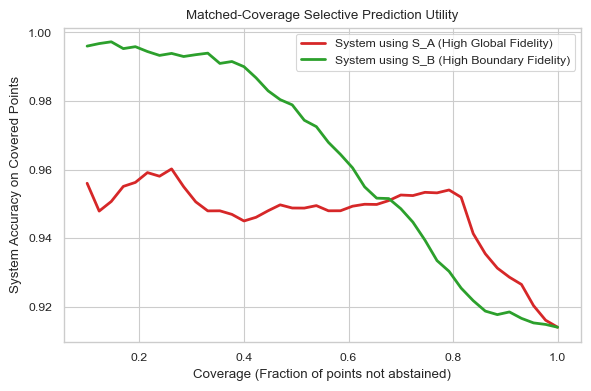

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(coverages, acc_a_curve, label="System using S_A (High Global Fidelity)", lw=2, color='tab:red')
plt.plot(coverages, acc_b_curve, label="System using S_B (High Boundary Fidelity)", lw=2, color='tab:green')
plt.xlabel("Coverage (Fraction of points not abstained)")
plt.ylabel("System Accuracy on Covered Points")
plt.title("Matched-Coverage Selective Prediction Utility")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/selective_prediction_utility.pdf")
plt.show()
